In [1]:
#| label: setup
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

OUTDIR = Path("/scratch/gpfs/AMOELLER/sidd/diet_manip/revision_July_2026/relative_abundance")
CELL_STATS = Path(
    "/scratch/gpfs/AMOELLER/sidd/diet_manip/revision_July_2026/relative_abundance"
    "/significant_sites_summary/significant_sites_mag_cell_stats_long.tsv"
)
RA_TABLE = "/scratch/gpfs/AMOELLER/sidd/diet_manip/revision_July_2026/relative_abundance/rel_abundance_by_cell.tsv"
TABLES, FIGURES = OUTDIR / "tables", OUTDIR / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

COMPARISON = "pre_end-fat_control"
MIN_MAGS = 10  # No regression on fewer than 10 MAGs
ALPHA = 0.05

mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 200,
        "font.size": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "figure.autolayout": False,
    }
)
# Olive green for divergence: a third family clearly apart from the rose/blue arms. Best CVD score
# of the greens (deutan 6.4 vs fat, all-pairs validated); legends carry the identity as backup.
UNIT_COLOR = {
    "parallelism: fat": "#C1666B",
    "parallelism: control": "#4281A4",
    "divergence (fat vs control)": "#6B8E23",
}
print(f"cell stats : {CELL_STATS}")
print(f"abundance  : {RA_TABLE}")
print(f"outputs    : {OUTDIR}")

cell stats : /scratch/gpfs/AMOELLER/sidd/diet_manip/revision_July_2026/relative_abundance/significant_sites_summary/significant_sites_mag_cell_stats_long.tsv
abundance  : /scratch/gpfs/AMOELLER/sidd/diet_manip/revision_July_2026/relative_abundance/rel_abundance_by_cell.tsv
outputs    : /scratch/gpfs/AMOELLER/sidd/diet_manip/revision_July_2026/relative_abundance


## Assembling the table

`test_type` and `group_analyzed` are normalized onto the abundance table's `test_family` / `group`,
then merged. The merge is asserted to consume **every** row on both sides — a cell with significance
but no abundance (or the reverse) is a data error, not something to drop.

In [2]:
#| label: assemble
TEST_FAMILY = {"single_sample_tTest": "single_sample", "two_sample_paired_tTest": "two_sample"}
UNIT_LABEL = {
    ("single_sample", "fat"): "parallelism: fat",
    ("single_sample", "control"): "parallelism: control",
    ("two_sample", ""): "divergence (fat vs control)",
}

cs = pd.read_csv(CELL_STATS, sep="\t", dtype={"group_analyzed": str})
cs["group_analyzed"] = cs["group_analyzed"].fillna("").astype(str)
cs = cs[(cs["comparison"] == COMPARISON) & (cs["test_type"].isin(TEST_FAMILY))].copy()
cs["test_family"] = cs["test_type"].map(TEST_FAMILY)
cs["group"] = np.where(cs["test_family"] == "two_sample", "", cs["group_analyzed"])
cs


,comparison,period,group_pair,test_type,group_analyzed,mag_id,n_total_sites,n_sig_p,n_sig_q,pct_sig_p,pct_sig_q,min_p_value,min_q_value,test_family,group
668,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1007_DASTool_bins_61,4411,214,0,4.851508,0.0,0.000131,0.314043,single_sample,control
669,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1007_DASTool_bins_SLG1007_bin.012,248,33,0,13.306452,0.0,0.000190,0.336077,single_sample,control
670,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1007_DASTool_bins_SLG1007_bin.42,873,95,0,10.882016,0.0,0.000063,0.313342,single_sample,control
671,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1008_DASTool_bins_16,205,11,0,5.365854,0.0,0.003338,0.457234,single_sample,control
672,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1102_DASTool_bins_117_sub,5762,981,0,17.025338,0.0,0.000058,0.312866,single_sample,control
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG1205_DASTool_bins_21,48,4,0,8.333333,0.0,0.011299,0.063310,two_sample,
990,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG422_DASTool_bins_3_sub,186,9,0,4.838710,0.0,0.027979,0.122101,two_sample,
991,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG422_DASTool_bins_SLG422_bin.4,257,25,0,9.727626,0.0,0.011596,0.064488,two_sample,
992,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG530_DASTool_bins_65,516,17,0,3.294574,0.0,0.011868,0.065533,two_sample,


In [3]:
ra = pd.read_csv(RA_TABLE, sep="\t", dtype={"group": str})
ra["group"] = ra["group"].fillna("")
ra


,comparison,period,group_pair,test_family,group,mag_id,ra_pre,ra_end,ra_mean,delta_ra,abs_mean_delta_ra,mean_abs_delta_ra,n_replicates,n_mice,delta_ra_fat,delta_ra_control,delta_ra_contrast,abs_mean_delta_ra_contrast,mean_abs_delta_ra_contrast
0,pre_end-fat_control,pre_end,fat_control,single_sample,control,SLG1007_DASTool_bins_61,0.475973,0.177984,0.326979,-0.297989,0.297989,0.320340,8,15,NaN,NaN,NaN,NaN,NaN
1,pre_end-fat_control,pre_end,fat_control,single_sample,control,SLG1007_DASTool_bins_SLG1007_bin.012,0.128834,0.131421,0.130127,0.002588,0.002588,0.069089,8,15,NaN,NaN,NaN,NaN,NaN
2,pre_end-fat_control,pre_end,fat_control,single_sample,control,SLG1007_DASTool_bins_SLG1007_bin.42,0.149725,0.133841,0.141783,-0.015884,0.015884,0.103202,8,15,NaN,NaN,NaN,NaN,NaN
3,pre_end-fat_control,pre_end,fat_control,single_sample,control,SLG1008_DASTool_bins_16,0.067485,0.097183,0.082334,0.029698,0.029698,0.076802,8,15,NaN,NaN,NaN,NaN,NaN
4,pre_end-fat_control,pre_end,fat_control,single_sample,control,SLG1102_DASTool_bins_117_sub,0.282382,0.972156,0.627269,0.689773,0.689773,0.689773,8,15,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,pre_end-fat_control,pre_end,fat_control,two_sample,,SLG887_DASTool_bins_SLG887_bin.70,1.649639,1.036461,1.343050,-0.613177,0.613177,0.755816,8,30,-1.008916,-0.217439,-0.791477,0.791477,0.827016
198,pre_end-fat_control,pre_end,fat_control,two_sample,,SLG942_DASTool_bins_105,0.324725,0.233372,0.279049,-0.091352,0.091352,0.207407,8,30,-0.215780,0.033075,-0.248855,0.248855,0.307756
199,pre_end-fat_control,pre_end,fat_control,two_sample,,SLG942_DASTool_bins_SLG942_bin.29,0.291380,0.137678,0.214529,-0.153702,0.153702,0.243061,8,30,-0.301664,-0.005740,-0.295925,0.295925,0.295925
200,pre_end-fat_control,pre_end,fat_control,two_sample,,SLG991_DASTool_bins_12,0.564920,1.010313,0.787617,0.445393,0.445393,0.676954,8,30,-0.224627,1.115413,-1.340040,1.340040,1.340040


In [4]:
KEYS = ["comparison", "period", "group_pair", "test_family", "group", "mag_id"]
d = cs.merge(ra, on=KEYS, how="outer", indicator=True, validate="one_to_one")
unmatched = d[d["_merge"] != "both"]
assert unmatched.empty, (
    f"{len(unmatched)} cell(s) present on only one side:\n"
    f"{unmatched[KEYS + ['_merge']].head(10).to_string(index=False)}"
)
d = d.drop(columns="_merge")
d


,comparison,period,group_pair,test_type,group_analyzed,mag_id,n_total_sites,n_sig_p,n_sig_q,pct_sig_p,...,delta_ra,abs_mean_delta_ra,mean_abs_delta_ra,n_replicates,n_mice,delta_ra_fat,delta_ra_control,delta_ra_contrast,abs_mean_delta_ra_contrast,mean_abs_delta_ra_contrast
0,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1007_DASTool_bins_61,4411,214,0,4.851508,...,-0.297989,0.297989,0.320340,8,15,NaN,NaN,NaN,NaN,NaN
1,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1007_DASTool_bins_SLG1007_bin.012,248,33,0,13.306452,...,0.002588,0.002588,0.069089,8,15,NaN,NaN,NaN,NaN,NaN
2,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1007_DASTool_bins_SLG1007_bin.42,873,95,0,10.882016,...,-0.015884,0.015884,0.103202,8,15,NaN,NaN,NaN,NaN,NaN
3,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1008_DASTool_bins_16,205,11,0,5.365854,...,0.029698,0.029698,0.076802,8,15,NaN,NaN,NaN,NaN,NaN
4,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1102_DASTool_bins_117_sub,5762,981,0,17.025338,...,0.689773,0.689773,0.689773,8,15,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG887_DASTool_bins_SLG887_bin.70,627,120,48,19.138756,...,-0.613177,0.613177,0.755816,8,30,-1.008916,-0.217439,-0.791477,0.791477,0.827016
198,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG942_DASTool_bins_105,1802,328,98,18.201998,...,-0.091352,0.091352,0.207407,8,30,-0.215780,0.033075,-0.248855,0.248855,0.307756
199,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG942_DASTool_bins_SLG942_bin.29,281,51,18,18.149466,...,-0.153702,0.153702,0.243061,8,30,-0.301664,-0.005740,-0.295925,0.295925,0.295925
200,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG991_DASTool_bins_12,679,173,82,25.478645,...,0.445393,0.445393,0.676954,8,30,-0.224627,1.115413,-1.340040,1.340040,1.340040


## Restricting to the divergence-tested MAGs

The question of record is about the MAGs the **divergence test** (`two_sample_paired_tTest`)
actually tested — the 62 MAGs with rows in its `p_value_summary`. Every unit, including the two
parallelism units, is therefore restricted to that set before any model is fit: the parallelism
regressions run on the divergence-tested MAGs that also carry a parallelism p-value, not on their
own larger universes (68 control / 72 fat). Same organisms in all three units, different tests.

In [5]:
#| label: subset-divergence-tested
# The divergence-tested set is read off the merged table itself (the two_sample rows), not
# hardcoded, so a rerun of the upstream pipeline propagates automatically.
div_mags = set(d.loc[d["test_family"] == "two_sample", "mag_id"])
n_before = d.groupby(["test_family", "group"])["mag_id"].nunique().rename("n_MAGs_all")
d = d[d["mag_id"].isin(div_mags)].copy()
n_after = d.groupby(["test_family", "group"])["mag_id"].nunique().rename("n_MAGs_divergence_tested")

subset_report = pd.concat([n_before, n_after], axis=1)
subset_report["n_dropped"] = subset_report["n_MAGs_all"] - subset_report["n_MAGs_divergence_tested"]
assert set(d.loc[d["test_family"] == "two_sample", "mag_id"]) == div_mags, (
    "the divergence unit itself must be untouched by the subset"
)
print(f"divergence-tested MAG set: {len(div_mags)} MAGs; {len(d)} cells remain")
print(subset_report.to_string())

divergence-tested MAG set: 62 MAGs; 186 cells remain
                       n_MAGs_all  n_MAGs_divergence_tested  n_dropped
test_family   group                                                   
single_sample control          68                        62          6
              fat              72                        62         10
two_sample                     62                        62          0


In [6]:
# No degenerate zeros -> -log10 stays finite. Verified for these 202 cells, but asserted so a future
# run that does produce one fails loudly instead of yielding an infinite response.
for col in ("min_p_value", "min_q_value"):
    bad = d[~(d[col] > 0)]
    assert bad.empty, f"{col} must be > 0 before taking a logarithm; {len(bad)} cell(s) violate it."

d["unit"] = [UNIT_LABEL[(f, g)] for f, g in zip(d["test_family"], d["group"])]
d["neglog10_p"] = -np.log10(d["min_p_value"])
d["neglog10_q"] = -np.log10(d["min_q_value"])
d["score"] = d["pct_sig_p"]
d


,comparison,period,group_pair,test_type,group_analyzed,mag_id,n_total_sites,n_sig_p,n_sig_q,pct_sig_p,...,n_mice,delta_ra_fat,delta_ra_control,delta_ra_contrast,abs_mean_delta_ra_contrast,mean_abs_delta_ra_contrast,unit,neglog10_p,neglog10_q,score
0,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1007_DASTool_bins_61,4411,214,0,4.851508,...,15,NaN,NaN,NaN,NaN,NaN,parallelism: control,3.881719,0.503010,4.851508
1,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1007_DASTool_bins_SLG1007_bin.012,248,33,0,13.306452,...,15,NaN,NaN,NaN,NaN,NaN,parallelism: control,3.720471,0.473561,13.306452
2,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1007_DASTool_bins_SLG1007_bin.42,873,95,0,10.882016,...,15,NaN,NaN,NaN,NaN,NaN,parallelism: control,4.203654,0.503981,10.882016
4,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1102_DASTool_bins_117_sub,5762,981,0,17.025338,...,15,NaN,NaN,NaN,NaN,NaN,parallelism: control,4.233190,0.504642,17.025338
5,pre_end-fat_control,pre_end,fat_control,single_sample_tTest,control,SLG1105_DASTool_bins_SLG1105_bin.71_sub,1760,166,0,9.431818,...,15,NaN,NaN,NaN,NaN,NaN,parallelism: control,3.304400,0.418802,9.431818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG887_DASTool_bins_SLG887_bin.70,627,120,48,19.138756,...,30,-1.008916,-0.217439,-0.791477,0.791477,0.827016,divergence (fat vs control),3.588944,1.602413,19.138756
198,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG942_DASTool_bins_105,1802,328,98,18.201998,...,30,-0.215780,0.033075,-0.248855,0.248855,0.307756,divergence (fat vs control),4.508349,1.602413,18.201998
199,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG942_DASTool_bins_SLG942_bin.29,281,51,18,18.149466,...,30,-0.301664,-0.005740,-0.295925,0.295925,0.295925,divergence (fat vs control),4.161984,1.602413,18.149466
200,pre_end-fat_control,pre_end,fat_control,two_sample_paired_tTest,,SLG991_DASTool_bins_12,679,173,82,25.478645,...,30,-0.224627,1.115413,-1.340040,1.340040,1.340040,divergence (fat vs control),5.578924,1.619566,25.478645


In [7]:
print(f"{len(d)} cells, {d['mag_id'].nunique()} MAGs")
print(d.groupby("unit").agg(
    n_MAGs=("mag_id", "nunique"),
    n_replicates=("n_replicates", "first"),
    n_mice=("n_mice", "first"),
    min_p=("min_p_value", "min"),
    min_q=("min_q_value", "min"),
).to_string())

186 cells, 62 MAGs
                             n_MAGs  n_replicates  n_mice         min_p     min_q
unit                                                                             
divergence (fat vs control)      62             8      30  7.056354e-08  0.016046
parallelism: control             62             8      15  5.289195e-07  0.195087
parallelism: fat                 62             8      15  4.020328e-09  0.000709


## Responses and models

Three responses; six models per unit, plus three contrast models for the divergence unit — every one
of them with a single predictor.

The contrast predictors mirror the divergence unit's own design on the abundance side: per cage,
(END − PRE change under fat) − (END − PRE change under control). They ask whether the MAGs whose
*abundance* responded differently to the two diets are also the ones whose *alleles* diverged.

### The abundance predictors, in plain language

Every predictor starts from the published Table S3 percentages and climbs the same ladder:
**mouse → replicate (cage) → cell**. Per mouse, END − PRE is taken first (each mouse is its own
baseline); per cage, the mice of one arm are averaged; per cell, the 8 cage values are aggregated.

Toy dataset — 2 cages instead of 8, same arm imbalance as the real study (RA in %):

| cage | arm | mouse | PRE | END | Δ(mouse) = END − PRE |
|---|---|---|---|---|---|
| A | fat | m1 | 2.0 | 6.0 | +4.0 |
| A | fat | m2 | 3.0 | 5.0 | +2.0 |
| A | control | m3 | 4.0 | 3.0 | −1.0 |
| A | control | m4 | 2.0 | 4.0 | +2.0 |
| B | fat | m5 | 3.0 | 2.0 | −1.0 |
| B | control | m6 | 3.0 | 1.0 | −2.0 |

Per cage and arm (average the mice): d_fat(A) = (+4+2)/2 = **+3.0**, d_fat(B) = **−1.0**;
d_ctrl(A) = (−1+2)/2 = **+0.5**, d_ctrl(B) = **−2.0**.

**Level — how abundant is the MAG?** (fat arm shown)

- `ra_pre` = mean over cages of the cage-mean PRE abundance = (2.5 + 3.0)/2 = **2.75**
- `ra_end` = same at END = (5.5 + 2.0)/2 = **3.75**
- `ra_mean` = (2.75 + 3.75)/2 = **3.25** — the overall "how big is this organism" number

**Change — how much did it move?** (fat arm shown; uses the cage deltas +3.0 and −1.0)

- `delta_ra` = mean of the cage deltas = (+3.0 − 1.0)/2 = **+1.0** — net shift, direction kept
- `abs_mean_delta_ra` = |+1.0| = **1.0** — size of the *net* shift; cages moving opposite ways cancel first
- `mean_abs_delta_ra` = (|+3.0| + |−1.0|)/2 = **2.0** — how much a *typical* cage moved, no cancelling

The last two split exactly when cages disagree: here half the movement cancels (1.0 vs 2.0). The
control arm gets the same three numbers from its own cage deltas (+0.5, −2.0): delta_ra = **−0.75**,
abs_mean = **0.75**, mean_abs = **1.25**.

**Divergence unit — the same level and change measures, pooled over both arms.** The divergence row
describes the MAG across *all* (arm, cage) series — 16 in the real data, 4 in the toy — so its level
and change columns pool fat and control together:

- `ra_pre` = mean of the four cage-mean PREs = (2.5 + 3.0 + 3.0 + 3.0)/4 = **2.875** — with equal
  cages per arm this is just the average of the two arms' `ra_pre` (2.75 and 3.0)
- `ra_end` = (5.5 + 2.0 + 3.5 + 1.0)/4 = **3.0**, and `ra_mean` = (2.875 + 3.0)/2 = **2.94**
- `delta_ra` = mean of all four cage deltas = (+3.0 − 1.0 + 0.5 − 2.0)/4 = **+0.125**
- `abs_mean_delta_ra` = |+0.125| = **0.125**; `mean_abs_delta_ra` = (3.0 + 1.0 + 0.5 + 2.0)/4 = **1.625**

The pooled `delta_ra` mixes diet-driven change with change both arms share (drift, aging, cage
effects) — it says "this MAG moved," not "the diets disagreed about it." Separating those two is
exactly the job of the contrast family.

**Contrast — did fat move *differently* from control?** (divergence unit only)

The divergence test never asks "did the MAG change" — it asks, *within each cage pair*, "did the fat
side change differently from the control side". The contrast is the abundance-side quantity with
that exact shape, a difference-in-differences computed per cage first:

- cage A: c(A) = d_fat(A) − d_ctrl(A) = +3.0 − (+0.5) = **+2.5**
- cage B: c(B) = d_fat(B) − d_ctrl(B) = −1.0 − (−2.0) = **+1.0**

then aggregated three ways, mirroring the change family:

- `delta_ra_contrast` = mean of c = (+2.5 + 1.0)/2 = **+1.75** — fat rose ~1.75 points more than control, net
- `abs_mean_delta_ra_contrast` = |+1.75| = **1.75** — size of that net difference
- `mean_abs_delta_ra_contrast` = (|+2.5| + |+1.0|)/2 = **1.75** — typical cage's arm gap, no cancelling

All three coincide here because both cages point the same way; had c(B) been −1.0, the signed mean
would be +0.75 but the typical gap still 1.75 — that split (cages disagreeing) is high variance,
which *weakens* a paired test. Why the contrast matters: a MAG that doubled in **every** mouse
regardless of diet has a large pooled `delta_ra` but a contrast near zero — and that is exactly the
MAG the divergence test should *not* flag. Real example: `SLG191_DASTool_bins_89` crashed only under
fat (d_fat = −1.12, d_ctrl = +0.01), so its contrast is −1.13 — almost entirely diet-driven change.

In [8]:
#| label: spec
RESPONSES = {
    "neglog10_p": "-log10(min p-value)",
    "neglog10_q": "-log10(min q-value)",
    "score": "breadth: % of sites p<0.05",
}
# (model, column, log10?, group) -- `two_sample_only` models are skipped for the parallelism units.
MODELS = [
    ("level: PRE",           "ra_pre",                     True,  "level",    False),
    ("level: END",           "ra_end",                     True,  "level",    False),
    ("level: mean",          "ra_mean",                    True,  "level",    False),
    ("change:signed",       "delta_ra",                   False, "change",   False),
    ("change: |mean delta|", "abs_mean_delta_ra",          False, "change",   False),
    ("change: mean |delta|", "mean_abs_delta_ra",          False, "change",   False),
    ("contrast: signed",     "delta_ra_contrast",          False, "contrast", True),
    ("contrast: |mean|",     "abs_mean_delta_ra_contrast", False, "contrast", True),
    ("contrast: mean |c|",   "mean_abs_delta_ra_contrast", False, "contrast", True),
]
spec = pd.DataFrame(MODELS, columns=["model", "column", "log10", "family", "two_sample_only"])
spec

,model,column,log10,family,two_sample_only
0,level: PRE,ra_pre,True,level,False
1,level: END,ra_end,True,level,False
2,level: mean,ra_mean,True,level,False
3,change:signed,delta_ra,False,change,False
4,change: |mean delta|,abs_mean_delta_ra,False,change,False
5,change: mean |delta|,mean_abs_delta_ra,False,change,False
6,contrast: signed,delta_ra_contrast,False,contrast,True
7,contrast: |mean|,abs_mean_delta_ra_contrast,False,contrast,True
8,contrast: mean |c|,mean_abs_delta_ra_contrast,False,contrast,True


In [9]:
#| label: fit
def fit_one(sub, ycol, xcol, use_log10):
    """One univariate OLS plus a Spearman companion. Returns a dict, or a skip reason.

    The predictor is z-scored so beta reads as "per 1 SD of the predictor". Spearman is computed on
    the untransformed predictor: with n = 61-62 and heavily right-skewed abundance, a rank statistic
    that disagrees with OLS is itself informative.
    """
    s = sub[[ycol, xcol]].dropna()
    n_before = len(s)
    if use_log10:
        s = s[s[xcol] > 0]            # log undefined at zero abundance
    n_dropped = n_before - len(s)
    if len(s) < MIN_MAGS:
        return {"skipped_reason": f"n={len(s)} < {MIN_MAGS}", "n_MAGs": len(s), "n_dropped": n_dropped}

    x_raw = s[xcol].to_numpy(float)
    y = s[ycol].to_numpy(float)
    # Abundance levels span ~70-fold with a heavy right tail (3 MAGs hold ~1/4 of the mass), so on a
    # linear scale the most abundant MAGs get several times the average leverage on the slope. log10
    # spreads MAGs evenly and makes equal fold-changes equal distances. Change predictors are already
    # additive and can be <= 0, so they stay linear.
    x = np.log10(x_raw) if use_log10 else x_raw
    if np.std(x) == 0:
        return {"skipped_reason": "predictor has zero variance", "n_MAGs": len(s), "n_dropped": n_dropped}

    # Standardize the (logged) predictor. This rescales beta/se only; p and R2 are identical to the
    # unscaled fit.
    z = (x - x.mean()) / x.std(ddof=1)
    # y = b0 + b1*z (add_constant supplies the intercept column): b0 is the expected response for a
    # MAG of average abundance (z = 0), and p tests b1 = 0.
    # Ordinary Least Squares
    res = sm.OLS(y, sm.add_constant(z)).fit()
    # Rank-based companion on the same rows; ranks are invariant under log10, hence x_raw. Catches
    # any monotone trend and cannot be levered by the extreme-abundance MAGs.
    rho, rho_p = stats.spearmanr(x_raw, y)
    return {
        "n_MAGs": len(s), "n_dropped": n_dropped,
        "beta": res.params[1], "se": res.bse[1], "p": res.pvalues[1], "r2": res.rsquared,
        "spearman_rho": rho, "spearman_p": rho_p, "skipped_reason": "",
    }


rows = []
for unit, sub in d.groupby("unit"):
    is_two = sub["test_family"].iloc[0] == "two_sample"
    for _, m in spec.iterrows():
        if m["two_sample_only"] and not is_two:
            continue
        for resp, resp_label in RESPONSES.items():
            rows.append({
                "unit": unit, "response": resp, "response_label": resp_label,
                "model": m["model"], "family": m["family"], "predictor": m["column"],
                **fit_one(sub, resp, m["column"], m["log10"]),
            })

fits = pd.DataFrame(rows)
fits


,unit,response,response_label,model,family,predictor,n_MAGs,n_dropped,beta,se,p,r2,spearman_rho,spearman_p,skipped_reason
0,divergence (fat vs control),neglog10_p,-log10(min p-value),level: PRE,level,ra_pre,62,0,-0.182945,0.165073,0.272170,0.020060,-0.097832,0.449368,
1,divergence (fat vs control),neglog10_q,-log10(min q-value),level: PRE,level,ra_pre,62,0,-0.010618,0.020395,0.604553,0.004497,-0.115807,0.370078,
2,divergence (fat vs control),score,breadth: % of sites p<0.05,level: PRE,level,ra_pre,62,0,-2.260077,1.617391,0.167451,0.031518,-0.298582,0.018411,
3,divergence (fat vs control),neglog10_p,-log10(min p-value),level: END,level,ra_end,62,0,0.086420,0.166380,0.605382,0.004476,0.087306,0.499837,
4,divergence (fat vs control),neglog10_q,-log10(min q-value),level: END,level,ra_end,62,0,-0.001938,0.020440,0.924764,0.000150,0.062332,0.630314,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,parallelism: fat,neglog10_q,-log10(min q-value),change: |mean delta|,change,abs_mean_delta_ra,62,0,-0.024026,0.039635,0.546692,0.006087,0.068876,0.594779,
59,parallelism: fat,score,breadth: % of sites p<0.05,change: |mean delta|,change,abs_mean_delta_ra,62,0,-3.184032,1.981524,0.113335,0.041258,-0.111078,0.390070,
60,parallelism: fat,neglog10_p,-log10(min p-value),change: mean |delta|,change,mean_abs_delta_ra,62,0,-0.162511,0.192765,0.402549,0.011707,-0.014530,0.910755,
61,parallelism: fat,neglog10_q,-log10(min q-value),change: mean |delta|,change,mean_abs_delta_ra,62,0,-0.045445,0.039321,0.252371,0.021777,-0.034857,0.787963,


In [10]:
# Raw p-values only, by choice: each (response x model) family holds at most 3 fits, so readers can
# judge multiplicity directly from the table rather than through a correction.
ok = fits["skipped_reason"].eq("") & fits["p"].notna()

fits = fits.sort_values(["response", "family", "model", "unit"]).reset_index(drop=True)
fits.to_csv(TABLES / "regression_results.tsv", sep="\t", index=False, float_format="%.6g")
print(f"{len(fits)} fits ({int((~ok).sum())} skipped) -> {TABLES / 'regression_results.tsv'}")

63 fits (0 skipped) -> /scratch/gpfs/AMOELLER/sidd/diet_manip/revision_July_2026/relative_abundance/tables/regression_results.tsv


## Results

β is per 1 SD of the predictor. p-values are reported raw (no multiple-testing correction).

In [11]:
#| label: results-table
show = fits[fits["skipped_reason"].eq("")].copy()
tbl = show[["response_label", "family", "model", "unit", "n_MAGs", "n_dropped",
            "beta", "p", "r2", "spearman_rho", "spearman_p"]]
(tbl.style
   .format({"beta": "{:+.3f}", "p": "{:.3g}", "r2": "{:.3f}",
            "spearman_rho": "{:+.3f}", "spearman_p": "{:.3g}"})
   .map(lambda v: "background-color: #a1d99b" if v < ALPHA else "", subset=["p"])
   .hide(axis="index"))

response_label,family,model,unit,n_MAGs,n_dropped,beta,p,r2,spearman_rho,spearman_p
-log10(min p-value),change,change: mean |delta|,divergence (fat vs control),62,0,-0.008,0.96,0.000,+0.019,0.883
-log10(min p-value),change,change: mean |delta|,parallelism: control,62,0,+0.038,0.734,0.002,+0.057,0.661
-log10(min p-value),change,change: mean |delta|,parallelism: fat,62,0,-0.163,0.403,0.012,-0.015,0.911
-log10(min p-value),change,change: |mean delta|,divergence (fat vs control),62,0,+0.032,0.849,0.001,+0.071,0.585
-log10(min p-value),change,change: |mean delta|,parallelism: control,62,0,+0.074,0.508,0.007,+0.114,0.377
-log10(min p-value),change,change: |mean delta|,parallelism: fat,62,0,-0.010,0.957,0.000,+0.090,0.489
-log10(min p-value),change,change:signed,divergence (fat vs control),62,0,+0.215,0.195,0.028,+0.241,0.0593
-log10(min p-value),change,change:signed,parallelism: control,62,0,-0.101,0.365,0.014,-0.096,0.458
-log10(min p-value),change,change:signed,parallelism: fat,62,0,+0.135,0.487,0.008,+0.051,0.696
-log10(min p-value),contrast,contrast: mean |c|,divergence (fat vs control),62,0,+0.050,0.767,0.001,+0.101,0.434


### Which associations are significant?

In [12]:
#| label: summary
sig = show[show["p"] < ALPHA]
if sig.empty:
    print(f"No association has p < {ALPHA}.")
else:
    print(f"{len(sig)} of {len(show)} fits have p < {ALPHA} (uncorrected):\n")
    print(sig[["response_label", "model", "unit", "n_MAGs", "beta", "p", "spearman_rho", "spearman_p"]]
          .to_string(index=False, float_format=lambda v: f"{v:.4g}"))

5 of 63 fits have p < 0.05 (uncorrected):

            response_label                model             unit  n_MAGs     beta        p  spearman_rho  spearman_p
       -log10(min q-value)           level: END parallelism: fat      61 -0.08675  0.02921       -0.1415      0.2768
breadth: % of sites p<0.05 change: mean |delta| parallelism: fat      62   -4.587  0.02101       -0.2448     0.05517
breadth: % of sites p<0.05           level: END parallelism: fat      61   -4.654  0.01521       -0.3574    0.004691
breadth: % of sites p<0.05           level: PRE parallelism: fat      62   -6.064 0.001896       -0.4095   0.0009487
breadth: % of sites p<0.05          level: mean parallelism: fat      62   -5.499 0.005181       -0.3722    0.002892


All five significant fits sit in one unit (parallelism: fat), four of them in one predictor family
(abundance level), all with negative β: **among the divergence-tested MAGs, the less abundant a MAG,
the stronger and broader its fat-arm parallelism signal**. The strongest — breadth vs PRE abundance
(β = −6.1 points per SD of log abundance, p = 1.9 × 10⁻³, Spearman ρ = −0.41) — is the same
association the full-universe analysis found; restricting to the 62 divergence-tested MAGs left it
essentially unchanged. The fifth hit (breadth vs mean |delta|, p = 0.021) adds little that is new:
its Spearman companion is not significant (ρ = −0.24, p = 0.055), and the absolute-change predictors
themselves track abundance level (see README), so it largely restates the level association. With
63 uncorrected tests, ~3 hits are expected by chance; what carries weight is not the count but the
clustering in one unit × family, the consistent sign, and the Spearman agreement. The direction is
the informative part: a depth-driven artifact would produce the *opposite* association (more
abundant → deeper coverage → more power → more significance), so the significance AlleleFlux reports
is not an artifact of abundance. The control arm and the divergence unit show no association at all.

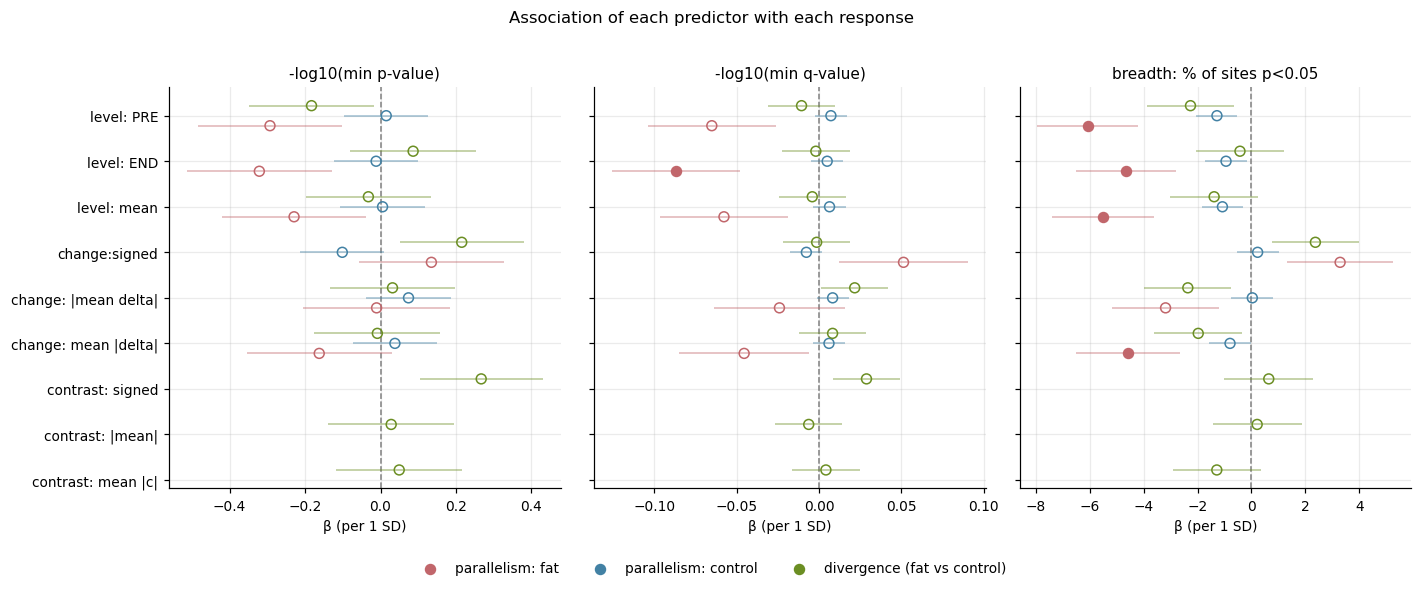

In [13]:
#| label: fig-beta-dotplot
#| fig-cap: "β per 1 SD, one point per fit. Filled = p < 0.05 (uncorrected), hollow = not."
units = list(UNIT_COLOR)
fig, axes = plt.subplots(1, 3, figsize=(13, 5.2), sharey=True)
models = list(spec["model"])
ypos = {m: i for i, m in enumerate(models[::-1])}
for ax, (resp, label) in zip(axes, RESPONSES.items()):
    sub = show[show["response"] == resp]
    ax.axvline(0, ls="--", c="grey", lw=1)
    for unit in units:
        u = sub[sub["unit"] == unit]
        filled = u["p"] < ALPHA
        y = [ypos[m] + 0.22 * (units.index(unit) - 1) for m in u["model"]]
        ax.errorbar(u["beta"], y, xerr=u["se"], fmt="none", ecolor=UNIT_COLOR[unit], alpha=0.5, lw=1)
        ax.scatter(u["beta"][filled], np.array(y)[filled.to_numpy()],
                   color=UNIT_COLOR[unit], s=42, zorder=3, label=unit)
        ax.scatter(u["beta"][~filled], np.array(y)[~filled.to_numpy()],
                   facecolors="none", edgecolors=UNIT_COLOR[unit], s=42, zorder=3)
    ax.set_yticks(range(len(models)), models[::-1])
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("β (per 1 SD)")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Association of each predictor with each response", y=0.99)
fig.tight_layout(rect=(0, 0.05, 1, 0.97))
fig.savefig(FIGURES / "beta_dotplot.pdf", bbox_inches="tight")
plt.show()

## Abundance level vs. significance

DRIDO's Fig 1a/1b: does the signal track sequencing depth? A flat fit is reassuring.

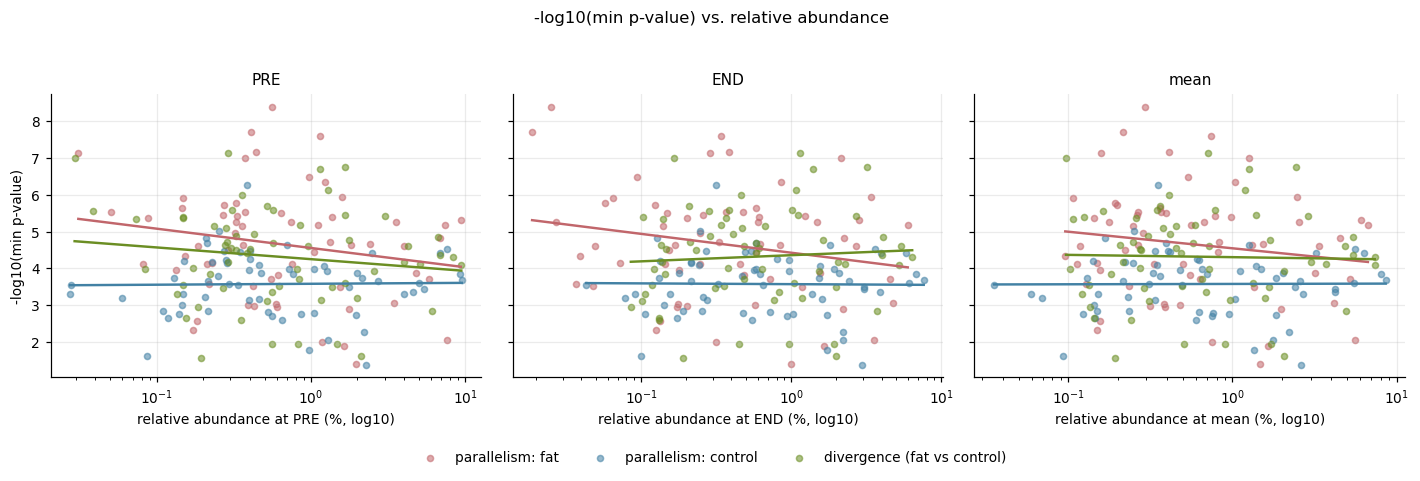

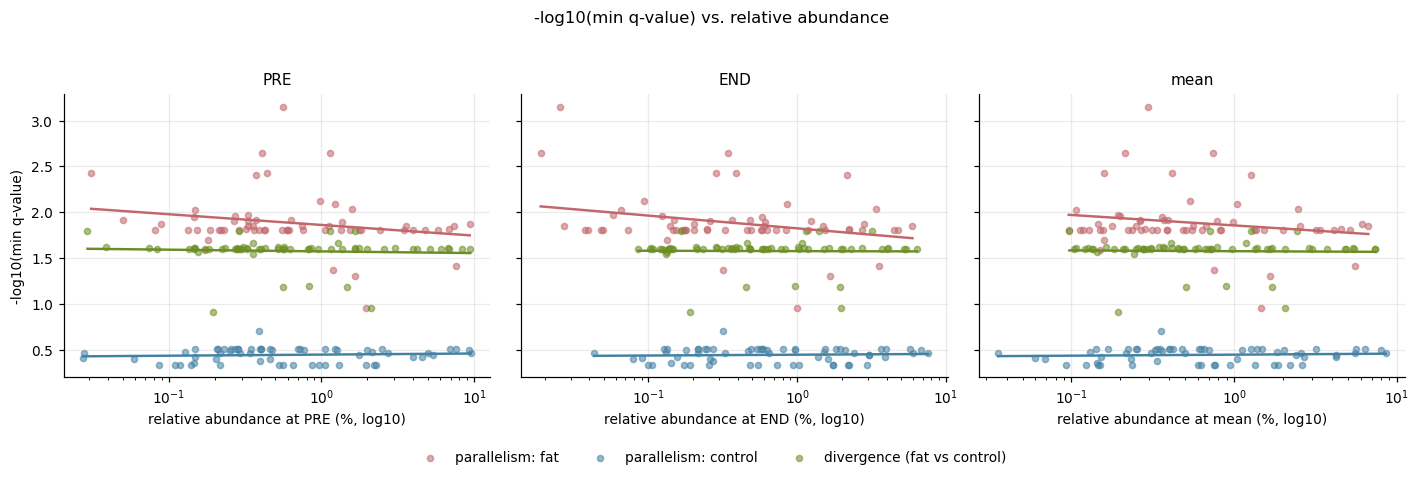

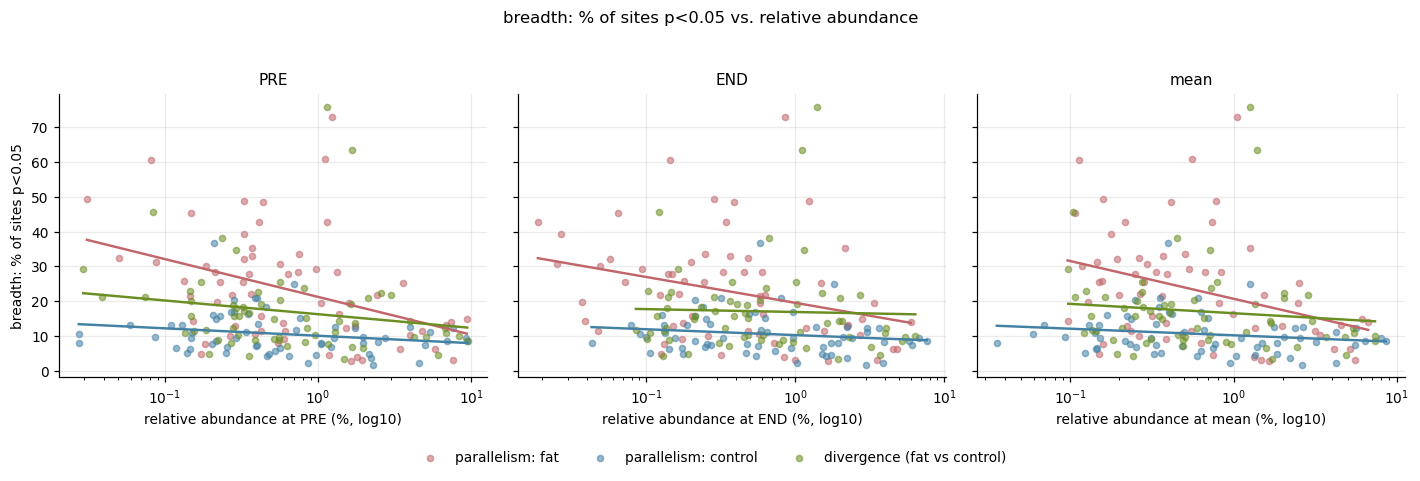

In [14]:
#| label: fig-abundance
#| fig-cap: "Response vs. relative abundance (log10 x). Columns = abundance variant, rows = response."
VARIANTS = [("ra_pre", "PRE"), ("ra_end", "END"), ("ra_mean", "mean")]
for resp, label in RESPONSES.items():
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), sharey=True)
    for ax, (col, vlabel) in zip(axes, VARIANTS):
        for unit in units:
            u = d[(d["unit"] == unit) & (d[col] > 0)]
            ax.scatter(u[col], u[resp], s=16, alpha=0.55, color=UNIT_COLOR[unit], label=unit)
            if len(u) >= MIN_MAGS:
                lx = np.log10(u[col].to_numpy(float))
                b = np.polyfit(lx, u[resp].to_numpy(float), 1)
                xs = np.linspace(lx.min(), lx.max(), 50)
                ax.plot(10**xs, np.polyval(b, xs), color=UNIT_COLOR[unit], lw=1.6)
        ax.set_xscale("log")
        ax.set_xlabel(f"relative abundance at {vlabel} (%, log10)")
        ax.set_title(f"{vlabel}", fontsize=10)
    axes[0].set_ylabel(label)
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.06))
    fig.suptitle(f"{label} vs. relative abundance", y=1.0)
    fig.tight_layout(rect=(0, 0.02, 1, 0.96))
    fig.savefig(FIGURES / f"abundance_vs_{resp}.pdf", bbox_inches="tight")
    plt.show()

## Change in abundance vs. significance

Signed change on the left (did rising or falling matter?), magnitude on the right (did moving at all
matter?). The dashed vertical marks no change.

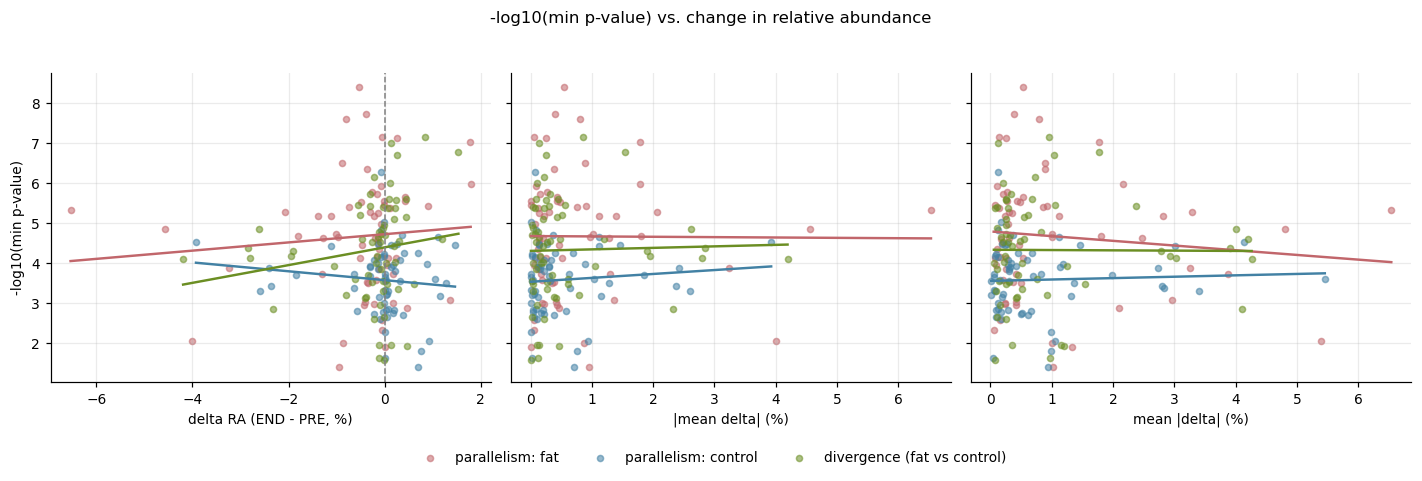

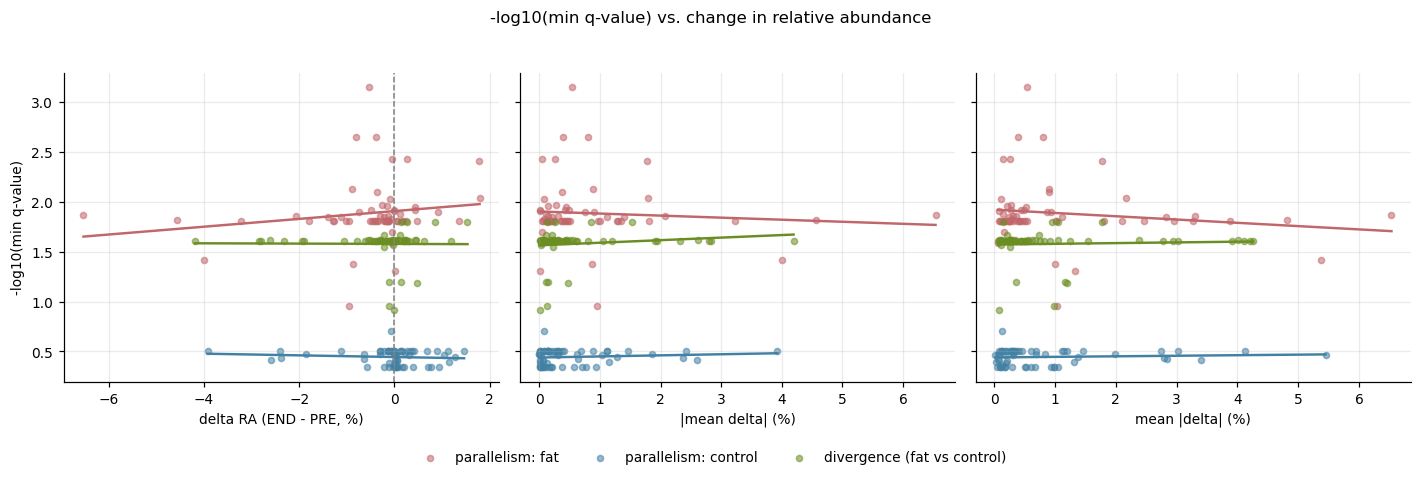

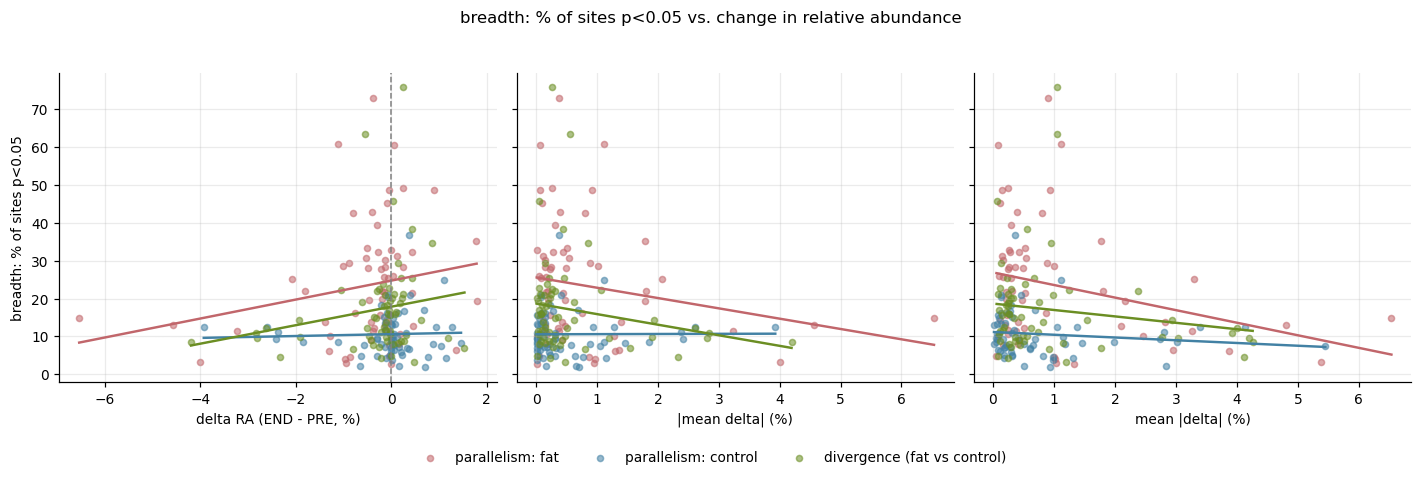

In [15]:
#| label: fig-change
#| fig-cap: "Response vs. change in relative abundance."
CHANGE_PANELS = [("delta_ra", "delta RA (END - PRE, %)"),
                 ("abs_mean_delta_ra", "|mean delta| (%)"),
                 ("mean_abs_delta_ra", "mean |delta| (%)")]
for resp, label in RESPONSES.items():
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), sharey=True)
    for ax, (col, xlabel) in zip(axes, CHANGE_PANELS):
        for unit in units:
            u = d[d["unit"] == unit]
            ax.scatter(u[col], u[resp], s=16, alpha=0.55, color=UNIT_COLOR[unit], label=unit)
            if len(u) >= MIN_MAGS:
                b = np.polyfit(u[col].to_numpy(float), u[resp].to_numpy(float), 1)
                xs = np.linspace(u[col].min(), u[col].max(), 50)
                ax.plot(xs, np.polyval(b, xs), color=UNIT_COLOR[unit], lw=1.6)
        if col == "delta_ra":
            ax.axvline(0, ls="--", c="grey", lw=1)
        ax.set_xlabel(xlabel)
    axes[0].set_ylabel(label)
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc="lower center", ncol=3, frameon=False, bbox_to_anchor=(0.5, -0.06))
    fig.suptitle(f"{label} vs. change in relative abundance", y=1.0)
    fig.tight_layout(rect=(0, 0.02, 1, 0.96))
    fig.savefig(FIGURES / f"delta_vs_{resp}.pdf", bbox_inches="tight")
    plt.show()

## Abundance trajectory

DRIDO's Fig 3, descriptive. Both axes are log10 (labeled in original % units), so equal fold-changes
are equal distances; points above the dashed `y = x` rose from PRE to END.

Because a log axis cannot display zero, MAGs at 0% abundance at either timepoint are excluded and
the exclusion is stamped on the panel title. In practice this affects only *parallelism: fat*, which
plots **61 of the 62 MAGs**: `SLG191_DASTool_bins_89` dropped to 0% in every fat-arm mouse by END
(its fat-arm `ra_end` is exactly 0), so it has no position on the y-axis. Ironically that makes the
single most diet-responsive faller invisible here — its story is told by the change/contrast columns
instead. The control and divergence panels keep all 62 (the divergence unit pools both arms, so its
END mean stays above zero).

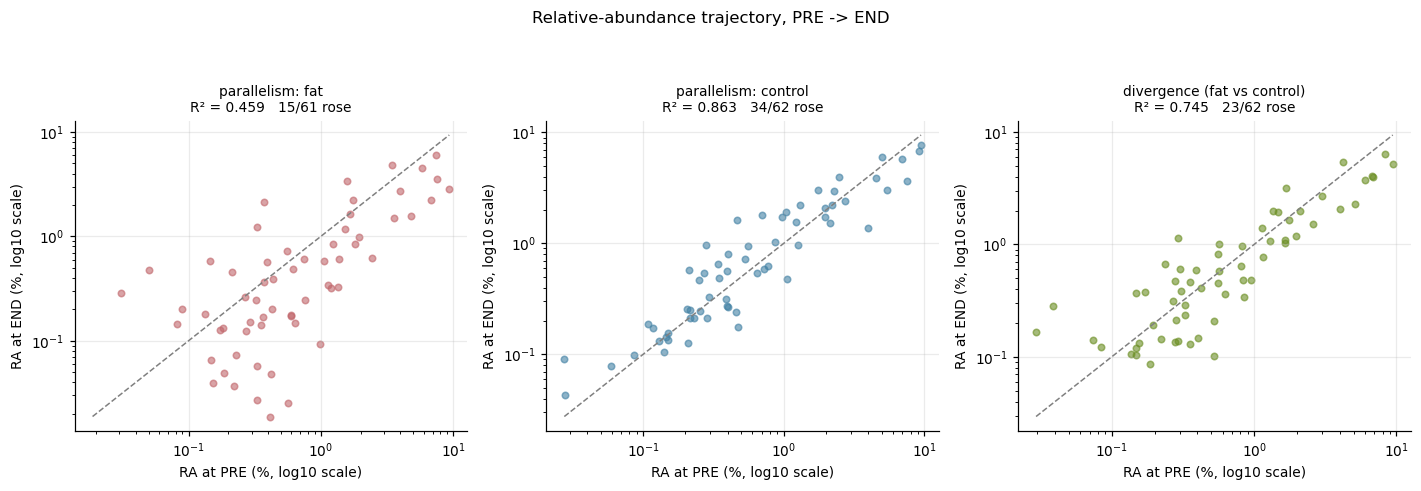

In [16]:
#| label: fig-trajectory
#| fig-cap: "PRE vs END relative abundance per MAG, log-log."
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, unit in zip(axes, units):
    full = d[d["unit"] == unit]
    u = full[(full["ra_pre"] > 0) & (full["ra_end"] > 0)]
    # Log axes cannot show zero, so MAGs at 0% at either timepoint are excluded from this plot
    # (parallelism: fat loses exactly one, SLG191_DASTool_bins_89, which hit 0% in every fat-arm
    # mouse by END). The exclusion is counted in the panel title so the n is never silent.
    ax.scatter(u["ra_pre"], u["ra_end"], s=18, alpha=0.6, color=UNIT_COLOR[unit])
    lo = min(u["ra_pre"].min(), u["ra_end"].min())
    hi = max(u["ra_pre"].max(), u["ra_end"].max())
    ax.plot([lo, hi], [lo, hi], ls="--", c="grey", lw=1)
    lx, ly = np.log10(u["ra_pre"].to_numpy(float)), np.log10(u["ra_end"].to_numpy(float))
    r2 = np.corrcoef(lx, ly)[0, 1] ** 2
    n_up = int((u["ra_end"] > u["ra_pre"]).sum())
    # Same "(%, log10)" label convention as the abundance-level panels above.
    ax.set(xscale="log", yscale="log",
           xlabel="RA at PRE (%, log10 scale)", ylabel="RA at END (%, log10 scale)")
    ax.set_title(f"{unit}\nR² = {r2:.3f}   {n_up}/{len(u)} rose", fontsize=9)
fig.suptitle("Relative-abundance trajectory, PRE -> END", y=1.0)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(FIGURES / "trajectory_pre_end.pdf", bbox_inches="tight")
plt.show()